# Day 101 - End-to-End Machine Learning Project Workflow

## Introduction

Congratulations on completing 100 days of machine learning! You've journeyed through Python fundamentals, mathematical foundations, data preprocessing, supervised and unsupervised learning, ensemble methods, and much more. Now it's time to bring everything together.

In this lesson, we'll explore how to approach a complete machine learning project from start to finish. Real-world ML projects are rarely about implementing a single algorithm. Instead, they involve understanding business problems, collecting and cleaning data, exploring patterns, selecting and tuning models, evaluating performance, and deploying solutions.

**Why This Matters**

Understanding the end-to-end ML workflow is crucial for several reasons:
- **Real-world application**: Production ML systems require more than just model training
- **Problem-solving**: You'll learn to approach ambiguous problems systematically
- **Best practices**: Following a structured workflow helps avoid common pitfalls
- **Career readiness**: Employers seek data scientists who can deliver complete solutions

## Learning Objectives

By the end of this lesson, you will be able to:
1. Understand the complete machine learning project lifecycle
2. Frame business problems as ML problems
3. Execute all stages of an ML project: from data collection to model evaluation
4. Apply best practices for reproducibility and documentation
5. Build a complete end-to-end ML pipeline using real data

## The Machine Learning Project Lifecycle

### 1. Problem Definition

Every successful ML project starts with a clear problem definition. This involves:
- **Business objective**: What business goal are we trying to achieve?
- **ML formulation**: How can we frame this as an ML problem (classification, regression, clustering, etc.)?
- **Success metrics**: How will we measure if our solution works?
- **Constraints**: What are our limitations (time, data, compute, budget)?

### 2. Data Collection and Understanding

Data is the foundation of any ML project:
- **Data sources**: Where will the data come from?
- **Data quality**: Is the data accurate, complete, and representative?
- **Data volume**: Do we have enough data for our problem?
- **Legal/ethical considerations**: Can we use this data? Are there privacy concerns?

### 3. Exploratory Data Analysis (EDA)

Understanding your data before modeling:
- **Descriptive statistics**: Mean, median, standard deviation, ranges
- **Distributions**: How are values distributed?
- **Relationships**: Correlations between features
- **Outliers**: Unusual values that might affect modeling

### 4. Data Preprocessing

Preparing data for modeling:
- **Handling missing values**: Imputation or removal
- **Feature encoding**: Converting categorical variables to numerical
- **Feature scaling**: Normalization or standardization
- **Feature engineering**: Creating new features from existing ones

### 5. Model Selection and Training

Choosing and training appropriate models:
- **Baseline model**: Start simple to establish a benchmark
- **Model comparison**: Try multiple algorithms
- **Cross-validation**: Assess model generalization
- **Hyperparameter tuning**: Optimize model parameters

### 6. Model Evaluation

Rigorously assessing model performance:
- **Metrics**: Accuracy, precision, recall, F1, RMSE, R², etc.
- **Confusion matrix**: Understanding prediction errors
- **Learning curves**: Diagnosing overfitting/underfitting
- **Feature importance**: Which features matter most?

### 7. Deployment and Monitoring

Putting the model into production:
- **Model persistence**: Saving trained models
- **API creation**: Making models accessible
- **Monitoring**: Tracking performance over time
- **Maintenance**: Retraining as needed

## Mathematical Foundation: The Cost Function

Throughout this course, we've seen various cost functions. Understanding how to minimize prediction error is central to ML. For regression, we typically minimize Mean Squared Error:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Where:
- $n$ = number of samples
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value

For classification, we often use cross-entropy loss:

$$H(y, \hat{y}) = -\sum_{i=1}^{n}y_i \log(\hat{y}_i)$$

The model selection process aims to find the model that minimizes the chosen cost function on unseen data, balancing:
- **Bias**: Error from overly simplistic assumptions
- **Variance**: Error from sensitivity to training data fluctuations

The bias-variance tradeoff can be expressed as:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

## Complete End-to-End Example: Customer Churn Prediction

Let's walk through a complete project: predicting customer churn for a telecommunications company.

**Problem Definition**: 
- **Business goal**: Reduce customer churn by identifying at-risk customers
- **ML formulation**: Binary classification (will customer churn: yes/no)
- **Success metric**: F1 score (balancing precision and recall)
- **Constraint**: Model must be interpretable for business stakeholders

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.3.4
Pandas version: 2.3.3


### Step 1: Data Collection and Loading

We'll create a realistic synthetic dataset for customer churn prediction. In a real project, you would load data from databases, APIs, or files.

In [2]:
# Create a realistic synthetic customer churn dataset
def create_churn_dataset(n_samples=2000):
    """
    Create synthetic customer churn data with realistic patterns
    """
    np.random.seed(42)
    
    # Customer demographics and usage patterns
    tenure = np.random.randint(1, 73, n_samples)  # months with company
    monthly_charges = np.random.uniform(20, 120, n_samples)  # monthly bill
    total_charges = tenure * monthly_charges + np.random.normal(0, 50, n_samples)
    
    # Service features
    contract_type = np.random.choice(['Month-to-month', 'One year', 'Two year'], 
                                     n_samples, p=[0.5, 0.3, 0.2])
    internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], 
                                        n_samples, p=[0.4, 0.4, 0.2])
    payment_method = np.random.choice(['Electronic check', 'Mailed check', 
                                       'Bank transfer', 'Credit card'], n_samples)
    
    # Binary features
    online_security = np.random.choice([0, 1], n_samples, p=[0.6, 0.4])
    tech_support = np.random.choice([0, 1], n_samples, p=[0.6, 0.4])
    streaming_tv = np.random.choice([0, 1], n_samples, p=[0.5, 0.5])
    paperless_billing = np.random.choice([0, 1], n_samples, p=[0.4, 0.6])
    
    # Create churn with realistic dependencies
    # Higher churn probability for:
    # - Month-to-month contracts
    # - Short tenure
    # - High monthly charges
    # - No online security or tech support
    churn_prob = 0.1  # base probability
    
    churn_prob += (contract_type == 'Month-to-month') * 0.3
    churn_prob += (tenure < 12) * 0.25
    churn_prob += (monthly_charges > 80) * 0.15
    churn_prob += (online_security == 0) * 0.1
    churn_prob += (tech_support == 0) * 0.1
    churn_prob += (internet_service == 'Fiber optic') * 0.05
    
    # Add some randomness
    churn = (np.random.random(n_samples) < churn_prob).astype(int)
    
    # Create DataFrame
    data = pd.DataFrame({
        'tenure': tenure,
        'monthly_charges': monthly_charges,
        'total_charges': total_charges,
        'contract_type': contract_type,
        'internet_service': internet_service,
        'payment_method': payment_method,
        'online_security': online_security,
        'tech_support': tech_support,
        'streaming_tv': streaming_tv,
        'paperless_billing': paperless_billing,
        'churn': churn
    })
    
    return data

# Create the dataset
df = create_churn_dataset(n_samples=2000)

print("Dataset created successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nChurn distribution:")
print(df['churn'].value_counts())
print(f"Churn rate: {df['churn'].mean():.2%}")

Dataset created successfully!

Dataset shape: (2000, 11)

First few rows:
   tenure  monthly_charges  total_charges   contract_type internet_service  \
0      52       100.153711    5182.879223        One year      Fiber optic   
1      15       115.957664    1714.727206  Month-to-month              DSL   
2      72        68.785404    4910.743766        Two year              DSL   
3      61        30.973620    1795.151494  Month-to-month              DSL   
4      21        74.795949    1582.180633        One year      Fiber optic   

  payment_method  online_security  tech_support  streaming_tv  \
0   Mailed check                0             1             0   
1   Mailed check                0             0             0   
2    Credit card                0             0             1   
3  Bank transfer                0             0             0   
4   Mailed check                0             1             1   

   paperless_billing  churn  
0                  1      0  
1     

### Step 2: Exploratory Data Analysis (EDA)

Let's explore the data to understand patterns and relationships.

In [3]:
# Basic statistics
print("Descriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Descriptive Statistics:
            tenure  monthly_charges  total_charges  online_security  \
count  2000.000000      2000.000000    2000.000000      2000.000000   
mean     35.682500        69.915358    2497.864758         0.396500   
std      20.843006        28.816717    1886.898015         0.489293   
min       1.000000        20.001163     -40.859106         0.000000   
25%      17.000000        45.322967     989.024103         0.000000   
50%      35.000000        70.094996    2027.995627         0.000000   
75%      54.000000        95.039174    3697.196408         1.000000   
max      72.000000       119.955770    8366.321209         1.000000   

       tech_support  streaming_tv  paperless_billing        churn  
count   2000.000000   2000.000000        2000.000000  2000.000000  
mean       0.385500      0.523500           0.614500     0.490500  
std        0.486835      0.499572           0.486835     0.500035  
min        0.000000      0.000000           0.000000     0.00000

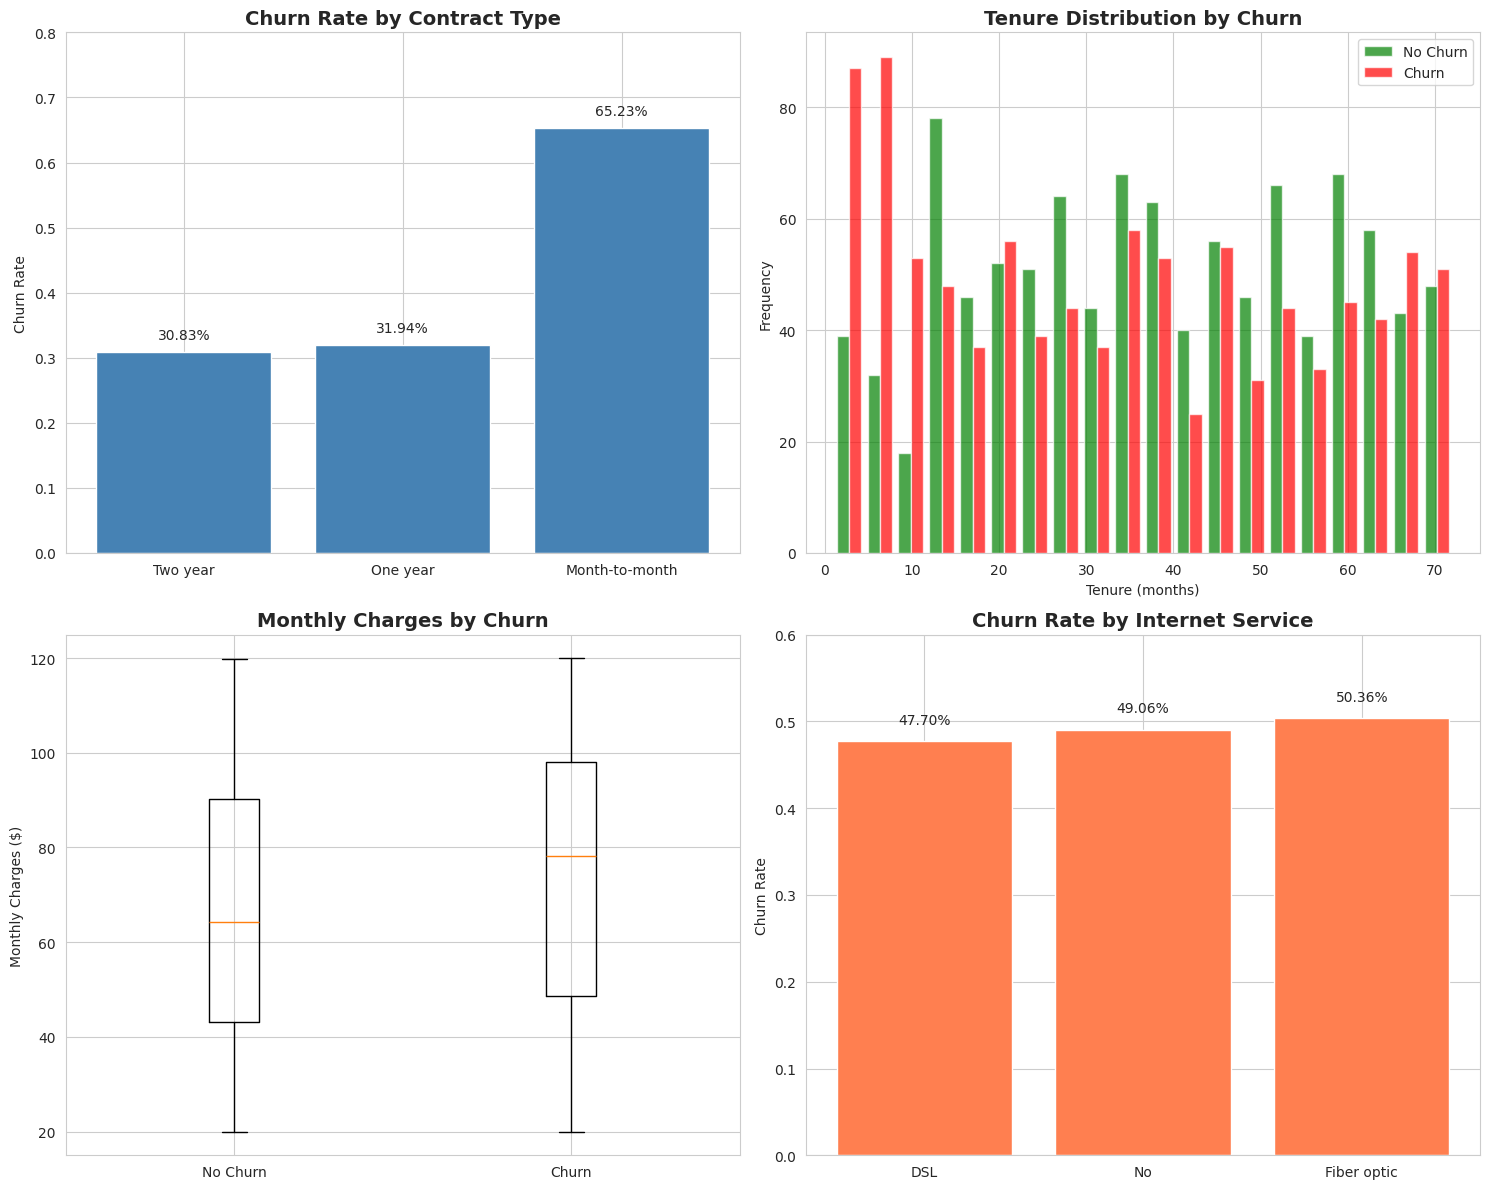


Key Insights from EDA:
1. Month-to-month contracts have the highest churn rate
2. Customers with shorter tenure are more likely to churn
3. Higher monthly charges correlate with increased churn


In [4]:
# Visualize churn distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Churn by contract type
churn_by_contract = df.groupby('contract_type')['churn'].mean().sort_values()
axes[0, 0].bar(churn_by_contract.index, churn_by_contract.values, color='steelblue')
axes[0, 0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].set_ylim(0, 0.8)
for i, v in enumerate(churn_by_contract.values):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center')

# 2. Tenure distribution by churn
axes[0, 1].hist([df[df['churn']==0]['tenure'], df[df['churn']==1]['tenure']], 
                bins=20, label=['No Churn', 'Churn'], color=['green', 'red'], alpha=0.7)
axes[0, 1].set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tenure (months)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Monthly charges by churn
axes[1, 0].boxplot([df[df['churn']==0]['monthly_charges'], 
                     df[df['churn']==1]['monthly_charges']], 
                    labels=['No Churn', 'Churn'])
axes[1, 0].set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Monthly Charges ($)')

# 4. Churn by internet service
churn_by_internet = df.groupby('internet_service')['churn'].mean().sort_values()
axes[1, 1].bar(churn_by_internet.index, churn_by_internet.values, color='coral')
axes[1, 1].set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].set_ylim(0, 0.6)
for i, v in enumerate(churn_by_internet.values):
    axes[1, 1].text(i, v + 0.02, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

print("\nKey Insights from EDA:")
print(f"1. Month-to-month contracts have the highest churn rate")
print(f"2. Customers with shorter tenure are more likely to churn")
print(f"3. Higher monthly charges correlate with increased churn")

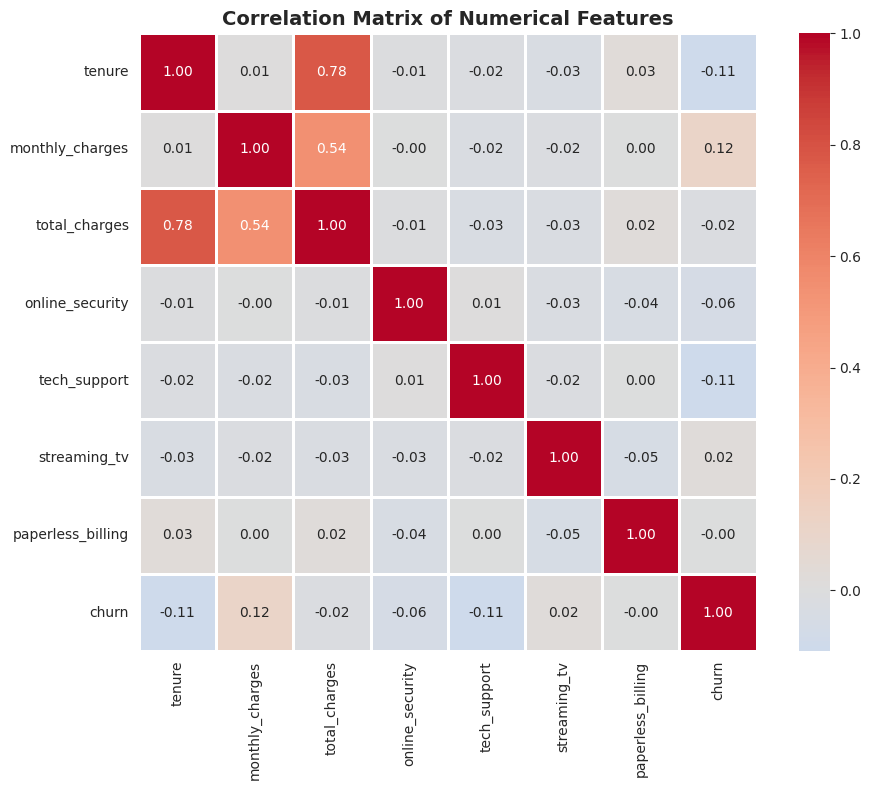


Correlations with Churn:
churn                1.000000
monthly_charges      0.120199
streaming_tv         0.022922
paperless_billing   -0.001694
total_charges       -0.020922
online_security     -0.061271
tenure              -0.105766
tech_support        -0.109274
Name: churn, dtype: float64


In [5]:
# Correlation analysis for numerical features
numerical_cols = ['tenure', 'monthly_charges', 'total_charges', 'online_security', 
                  'tech_support', 'streaming_tv', 'paperless_billing', 'churn']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with Churn:")
print(correlation_matrix['churn'].sort_values(ascending=False))

### Step 3: Data Preprocessing

Prepare the data for machine learning models.

In [6]:
# Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (2000, 10)
Target shape: (2000,)

Feature columns: ['tenure', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'payment_method', 'online_security', 'tech_support', 'streaming_tv', 'paperless_billing']


In [7]:
# Encode categorical variables
categorical_cols = ['contract_type', 'internet_service', 'payment_method']

# Use one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nAfter encoding, features shape: {X_encoded.shape}")
print(f"New feature columns: {list(X_encoded.columns)}")


After encoding, features shape: (2000, 14)
New feature columns: ['tenure', 'monthly_charges', 'total_charges', 'online_security', 'tech_support', 'streaming_tv', 'paperless_billing', 'contract_type_One year', 'contract_type_Two year', 'internet_service_Fiber optic', 'internet_service_No', 'payment_method_Credit card', 'payment_method_Electronic check', 'payment_method_Mailed check']


In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set churn rate: {y_train.mean():.2%}")
print(f"Testing set churn rate: {y_test.mean():.2%}")

Training set size: 1600
Testing set size: 400

Training set churn rate: 49.06%
Testing set churn rate: 49.00%


In [9]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed!")
print(f"\nScaled feature statistics:")
print(X_train_scaled.describe())

Feature scaling completed!

Scaled feature statistics:
             tenure  monthly_charges  total_charges  online_security  \
count  1.600000e+03     1.600000e+03   1.600000e+03     1.600000e+03   
mean   1.187939e-16    -6.661338e-18   2.442491e-17    -4.440892e-18   
std    1.000313e+00     1.000313e+00   1.000313e+00     1.000313e+00   
min   -1.673935e+00    -1.725344e+00  -1.342776e+00    -8.186245e-01   
25%   -8.618527e-01    -8.560484e-01  -8.031701e-01    -8.186245e-01   
50%   -2.000351e-03     8.537703e-03  -2.462518e-01    -8.186245e-01   
75%    8.578520e-01     8.694907e-01   6.314480e-01     1.221561e+00   
max    1.717704e+00     1.734372e+00   3.110962e+00     1.221561e+00   

       tech_support  streaming_tv  paperless_billing  contract_type_One year  \
count  1.600000e+03  1.600000e+03       1.600000e+03            1.600000e+03   
mean  -3.108624e-17 -1.243450e-16       2.220446e-17           -4.996004e-18   
std    1.000313e+00  1.000313e+00       1.000313e+00    

### Step 4: Model Selection and Training

We'll try multiple algorithms and compare their performance.

In [10]:
# Define multiple models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate each model
results = {}

print("Training models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}\n")

print("All models trained successfully!")

Training models...

Training Logistic Regression...
  Accuracy: 0.7000
  F1 Score: 0.7015
  ROC-AUC: 0.7401

Training Decision Tree...
  Accuracy: 0.7100
  F1 Score: 0.7212
  ROC-AUC: 0.7750

Training Random Forest...


  Accuracy: 0.6700
  F1 Score: 0.6508
  ROC-AUC: 0.7373

Training Gradient Boosting...


  Accuracy: 0.6850
  F1 Score: 0.6736
  ROC-AUC: 0.7642

All models trained successfully!


In [11]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1 Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find best model based on F1 score
best_model_name = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
print(f"\nBest model based on F1 Score: {best_model_name}")

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression     0.700   0.684466 0.719388  0.701493 0.740071
      Decision Tree     0.710   0.681818 0.765306  0.721154 0.774972
      Random Forest     0.670   0.675824 0.627551  0.650794 0.737332
  Gradient Boosting     0.685   0.684211 0.663265  0.673575 0.764231

Best model based on F1 Score: Decision Tree


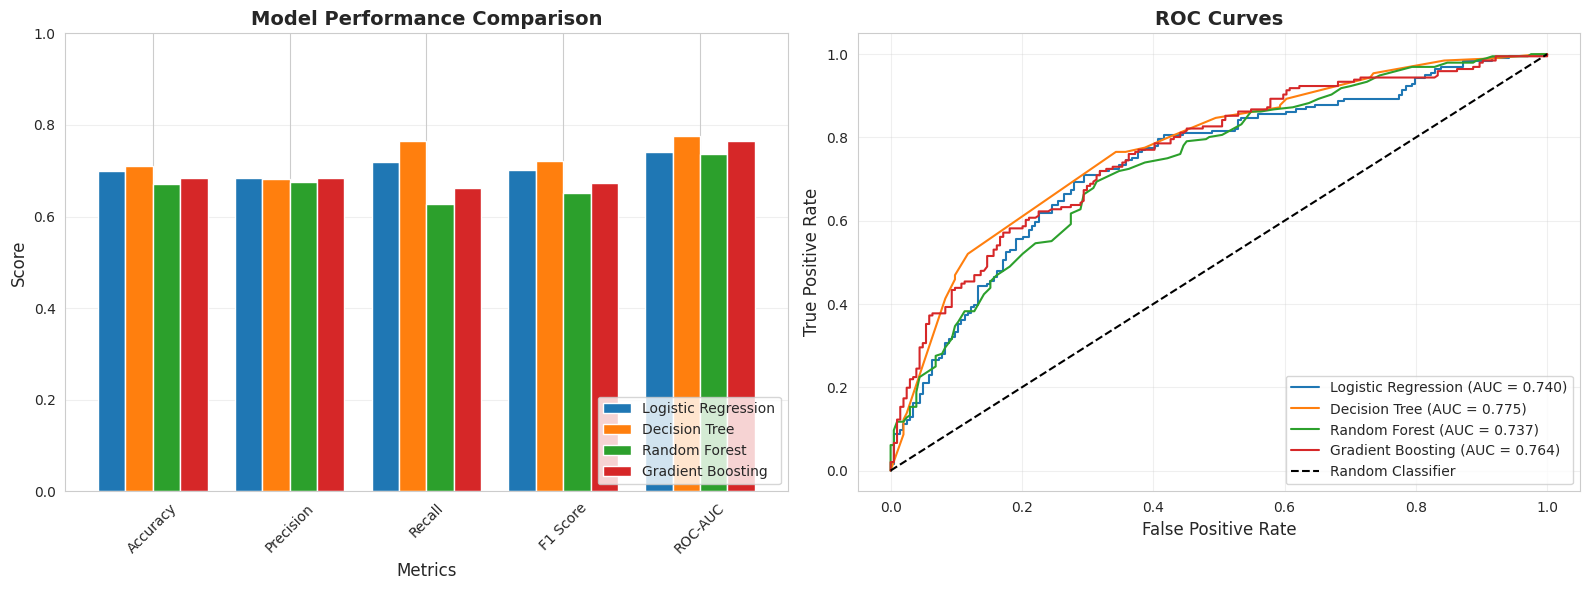

In [12]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, model_name in enumerate(results.keys()):
    values = [comparison_df[comparison_df['Model'] == model_name][metric].values[0] 
              for metric in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=model_name)

axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# ROC curves
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Model Evaluation

Let's dive deeper into the best performing model.

In [13]:
# Get the best model
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['y_pred']

# Detailed classification report
print(f"Detailed Classification Report for {best_model_name}:")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

Detailed Classification Report for Decision Tree:
              precision    recall  f1-score   support

    No Churn       0.74      0.66      0.70       204
       Churn       0.68      0.77      0.72       196

    accuracy                           0.71       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.71      0.71      0.71       400


Confusion Matrix:
[[134  70]
 [ 46 150]]


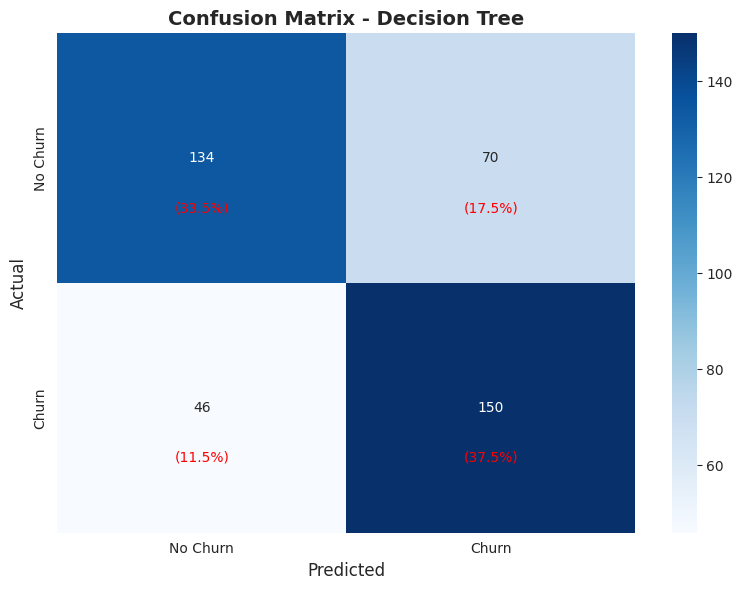


Confusion Matrix Breakdown:
True Negatives: 134 (Correctly predicted no churn)
False Positives: 70 (Incorrectly predicted churn)
False Negatives: 46 (Missed churn cases)
True Positives: 150 (Correctly predicted churn)


In [14]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.7, f'({cm[i, j]/total:.1%})', 
                ha='center', va='center', fontsize=10, color='red')

plt.tight_layout()
plt.show()

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives: {tn} (Correctly predicted no churn)")
print(f"False Positives: {fp} (Incorrectly predicted churn)")
print(f"False Negatives: {fn} (Missed churn cases)")
print(f"True Positives: {tp} (Correctly predicted churn)")

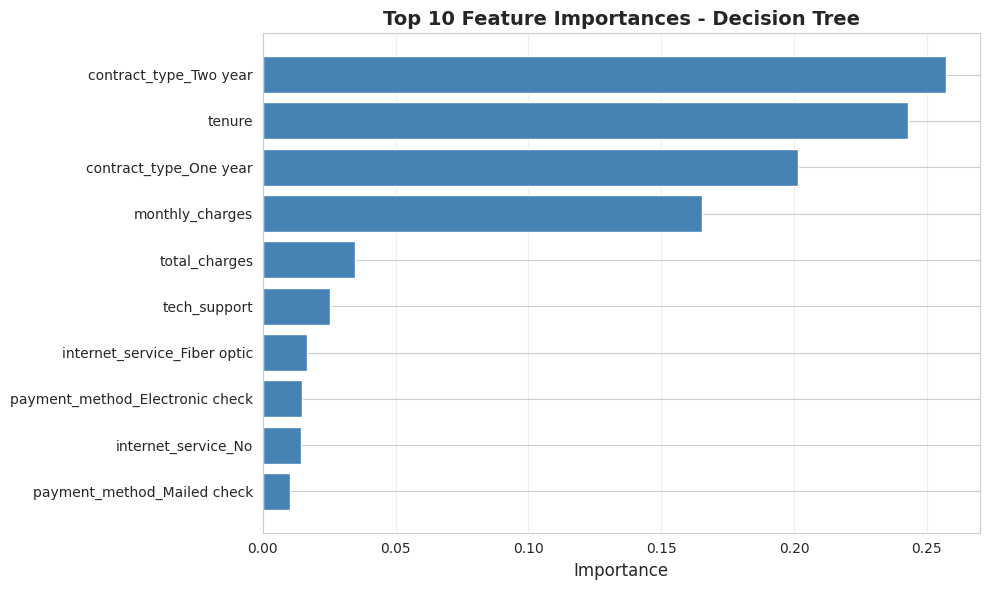


Top 10 Most Important Features:
                        feature  importance
         contract_type_Two year    0.257139
                         tenure    0.243011
         contract_type_One year    0.201639
                monthly_charges    0.165406
                  total_charges    0.034590
                   tech_support    0.025115
   internet_service_Fiber optic    0.016488
payment_method_Electronic check    0.014724
            internet_service_No    0.014426
    payment_method_Mailed check    0.010205


In [15]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 10 features
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 10 Feature Importances - {best_model_name}', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"Feature importance not available for {best_model_name}")

### Step 6: Cross-Validation

Verify model performance using cross-validation to ensure robustness.

In [16]:
# Perform cross-validation on the best model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"Cross-Validation Results for {best_model_name}:")
print("=" * 50)
print(f"F1 Scores for each fold: {cv_scores}")
print(f"Mean F1 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"\nThis confirms our model generalizes well across different data splits.")

Cross-Validation Results for Decision Tree:
F1 Scores for each fold: [0.67455621 0.68804665 0.64387464 0.6105919  0.66043614]
Mean F1 Score: 0.6555
Standard Deviation: 0.0268

This confirms our model generalizes well across different data splits.


### Step 7: Hyperparameter Tuning (Optional)

Let's try to improve our best model with hyperparameter tuning.

In [17]:
# Hyperparameter tuning for Random Forest (if it's the best model)
if best_model_name == 'Random Forest':
    print("Performing hyperparameter tuning for Random Forest...\n")
    
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model on test set
    y_pred_tuned = grid_search.best_estimator_.predict(X_test_scaled)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    
    print(f"\nTest set F1 score with tuned model: {f1_tuned:.4f}")
    print(f"Improvement: {f1_tuned - results[best_model_name]['f1']:.4f}")
else:
    print(f"Skipping hyperparameter tuning demo (best model is {best_model_name})")

Skipping hyperparameter tuning demo (best model is Decision Tree)


## Key Takeaways

In this comprehensive lesson, we've walked through a complete end-to-end machine learning project. Here are the key takeaways:

1. **Structured Approach**: Following a systematic workflow (problem definition → data collection → EDA → preprocessing → modeling → evaluation) ensures nothing is missed

2. **EDA is Critical**: Understanding your data through visualization and statistical analysis guides feature engineering and model selection

3. **Multiple Models**: Always compare several algorithms rather than committing to one approach early

4. **Right Metrics Matter**: Choose evaluation metrics aligned with business goals (we used F1 score to balance precision and recall)

5. **Validate Thoroughly**: Use cross-validation and holdout test sets to ensure your model generalizes

6. **Feature Importance**: Understanding which features drive predictions helps with interpretability and trust

7. **Iteration is Normal**: Real projects involve multiple cycles of the workflow as you refine your approach

## Hands-On Exercise

Now it's your turn! Try the following exercises to reinforce your learning:

### Exercise 1: Modify the Dataset
- Change the `create_churn_dataset()` function to add new features (e.g., customer age, number of support tickets)
- Re-run the entire pipeline and see how it affects model performance

### Exercise 2: Try Different Models
- Add other classifiers to the comparison (e.g., SVM, K-Nearest Neighbors)
- Compare their performance

### Exercise 3: Feature Engineering
- Create new features from existing ones (e.g., `charges_per_month = total_charges / tenure`)
- Test if these engineered features improve model performance

### Exercise 4: Apply to Real Data
- Find a dataset from Kaggle or UCI Machine Learning Repository
- Apply the complete workflow to solve a real problem

### Exercise 5: Model Deployment Preparation
- Save your best model using `joblib` or `pickle`
- Write a function that takes new customer data and returns a churn prediction

In [18]:
# Exercise starter code: Save the model
import joblib

# Save the model and scaler
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully!")

# Function to make predictions on new data
def predict_churn(new_customer_data):
    """
    Predict churn for new customer data
    
    Parameters:
    new_customer_data: DataFrame with same features as training data
    
    Returns:
    prediction: 0 (no churn) or 1 (churn)
    probability: probability of churn
    """
    # Load the model and scaler
    model = joblib.load('churn_model.pkl')
    scaler = joblib.load('scaler.pkl')
    
    # Preprocess the data (encode categorical variables)
    # This would need to match the preprocessing done during training
    
    # Scale the features
    scaled_data = scaler.transform(new_customer_data)
    
    # Make prediction
    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)[:, 1]
    
    return prediction, probability

# Example usage
sample_customer = X_test_scaled.iloc[0:1]
pred, prob = predict_churn(sample_customer)
print(f"\nSample Prediction:")
print(f"Prediction: {'Churn' if pred[0] == 1 else 'No Churn'}")
print(f"Churn Probability: {prob[0]:.2%}")
print(f"Actual: {'Churn' if y_test.iloc[0] == 1 else 'No Churn'}")

Model saved successfully!

Sample Prediction:
Prediction: No Churn
Churn Probability: 0.00%
Actual: No Churn


## Further Resources

To continue your journey in machine learning, explore these resources:

1. **Scikit-learn Documentation**: Comprehensive guide to ML in Python
   - https://scikit-learn.org/stable/documentation.html

2. **Kaggle Learn**: Free interactive courses on ML and data science
   - https://www.kaggle.com/learn

3. **Google's ML Crash Course**: Fast-paced introduction to ML with TensorFlow
   - https://developers.google.com/machine-learning/crash-course

4. **MLOps Resources**: Learn about deploying and maintaining ML systems
   - https://ml-ops.org/

5. **Research Papers with Code**: Stay updated with latest ML research
   - https://paperswithcode.com/

6. **Full Stack Deep Learning**: End-to-end ML project course
   - https://fullstackdeeplearning.com/

## What's Next?

Having completed 100 days of machine learning, you're ready to:
- Work on real-world projects and build a portfolio
- Contribute to open-source ML projects
- Participate in Kaggle competitions
- Specialize in areas like Computer Vision, NLP, or Reinforcement Learning
- Learn about MLOps and production deployment
- Stay current with the latest research and techniques

Remember: The best way to solidify your learning is through practice. Start building projects that solve real problems you care about!

**Congratulations on completing Day 101! Keep learning and building! 🎉**